<a href="https://colab.research.google.com/github/LukeXboy/MIE1517-Project/blob/main/6_fruits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#请记得多写注释，新增模块的功能，是否动了之前别人写的模块，改正的理由，等等。

In [ ]:
#授权colab访问google drive，登自己账号
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#找到6 fruits.rar在你设备上的目录
!find /content/drive/MyDrive -name "6 fruits.rar"

/content/drive/MyDrive/6 fruits.rar


In [ ]:
#把下面那个目录替换成你找到的目录，解压
!mkdir -p /content/data_raw
!apt-get install -y unrar
!unrar x "/content/drive/MyDrive/6 fruits.rar" /content/data_raw/
#!unrar x "/content/6 fruits.rar" /content/data_raw/

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/6 fruits.rar

Creating    /content/data_raw/Apple Red 2                             OK
Extracting  /content/data_raw/Apple Red 2/0_100.jpg                        0%  OK 
Extracting  /content/data_raw/Apple Red 2/100_100.jpg                      0%  OK 
Extracting  /content/data_raw/Apple Red 2/101_100.jpg                      0%  OK 
Extracting  /content/data_raw/Apple Red 2/102_100.jpg                      0%  OK 
Extracting  /content/data_raw/Apple Red 2/103_100.jpg                      0%  OK 
Extracting  /content/data_raw/Apple Red 2/104_100.jpg                      0%  OK 
Extracting  /content/data_r

In [ ]:
#验证解压结果，应该有6个水果文件夹
!ls /content/data_raw

'Apple Red 2'		'Kiwi 1'   'Orange 1'
'Banana Lady Finger 1'	'Lemon 1'  'Pear Monster 1'


In [ ]:
#Step 1：统计类别分布（Class Distribution），确认6类是否数量接近，为后续是否需要 class weighting 提供依据

import os
import pandas as pd

data_dir = "/content/data_raw"

classes = sorted(os.listdir(data_dir))

valid_extensions = (".jpg", ".jpeg", ".png")

class_counts = []

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(valid_extensions)]
    class_counts.append({
        "Class": cls,
        "Num Images": len(images)
    })

df_counts = pd.DataFrame(class_counts).sort_values(by="Num Images", ascending=False)
df_counts

,Class,Num Images
0,Apple Red 2,656
3,Lemon 1,656
5,Pear Monster 1,656
4,Orange 1,639
2,Kiwi 1,622
1,Banana Lady Finger 1,602


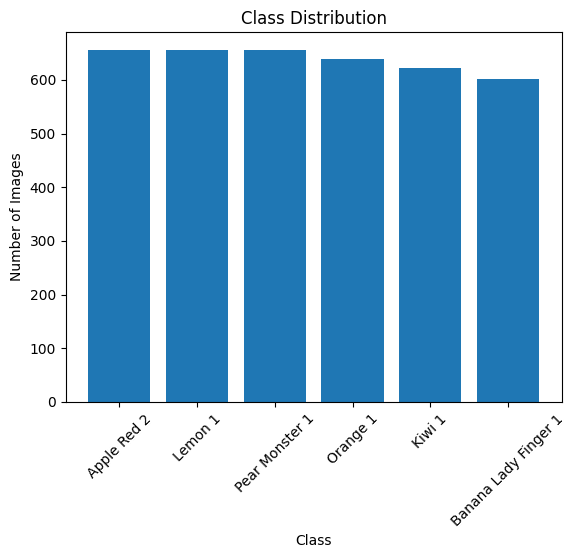

In [ ]:
#Step 2：画类别分布图

import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_counts["Class"], df_counts["Num Images"])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
#Step 3：检查极端小类别
print("Max:", df_counts["Num Images"].max())
print("Min:", df_counts["Num Images"].min())
print("Difference:", df_counts["Num Images"].max() - df_counts["Num Images"].min())

Max: 656
Min: 602
Difference: 54


In [ ]:
#Step 4：检测重复图像，因为 Fruits-360 是旋转拍摄，很可能存在高度相似图像，做简单 hash 检查。
import hashlib
from tqdm import tqdm

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(valid_extensions)]

    for img in tqdm(images):
        img_path = os.path.join(cls_path, img)
        h = file_hash(img_path)
        if h in hashes:
            duplicates.append((img_path, hashes[h]))
        else:
            hashes[h] = img_path

print("Number of duplicate images:", len(duplicates))

100%|██████████| 656/656 [00:00<00:00, 36833.51it/s]

Number of duplicate images: 0


In [ ]:
#Step 5：Stratified 70 / 15 / 15 split

In [ ]:
#Step 6：执行 stratified split
import random
import shutil

random.seed(0)

output_base = "/content/data_processed"

splits = ["train", "val", "test"]

# 创建目录
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(valid_extensions)]

    random.shuffle(images)

    n = len(images)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(output_base, "train", cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(output_base, "val", cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(output_base, "test", cls, img))

In [ ]:
#Step 7：验证 split
def count_split(split):
    split_dir = os.path.join(output_base, split)
    counts = {}
    for cls in classes:
        counts[cls] = len(os.listdir(os.path.join(split_dir, cls)))
    return counts

print("Train:", count_split("train"))
print("Val:", count_split("val"))
print("Test:", count_split("test"))

Train: {'Apple Red 2': 459, 'Banana Lady Finger 1': 421, 'Kiwi 1': 435, 'Lemon 1': 459, 'Orange 1': 447, 'Pear Monster 1': 459}
Val: {'Apple Red 2': 98, 'Banana Lady Finger 1': 90, 'Kiwi 1': 93, 'Lemon 1': 98, 'Orange 1': 96, 'Pear Monster 1': 98}
Test: {'Apple Red 2': 99, 'Banana Lady Finger 1': 91, 'Kiwi 1': 94, 'Lemon 1': 99, 'Orange 1': 96, 'Pear Monster 1': 99}


In [ ]:
#Step 8：100×100 分辨率是否足够？

'''
任务是水果分类

颜色 + 形状为主要特征

不是细粒度识别

100×100 足够：

ResNet18 默认输入 224×224

可 resize 到 224×224

信息不会丢失太多
'''

'\n任务是水果分类\n\n颜色 + 形状为主要特征\n\n不是细粒度识别\n\n100×100 足够：\n\nResNet18 默认输入 224×224\n\n可 resize 到 224×224\n\n信息不会丢失太多\n'

In [ ]:
#Step 8: 将图片resize到224x224

from torchvision import transforms
import torchvision

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train = torchvision.datasets.ImageFolder(
    root='/content/data_processed/train',
    transform=transform)

val = torchvision.datasets.ImageFolder(
    root='/content/data_processed/val',
    transform=transform)

test = torchvision.datasets.ImageFolder(
    root='/content/data_processed/test',
    transform=transform)

In [ ]:
#Step 9: 搭建ResNet18结构

import torch
import torch.nn as nn
from torchvision import models

class ResNet18Fruit(nn.Module):
    def __init__(self, num_classes=6, dropout=0.3):
        super().__init__()

        # Load pretrained backbone
        weights = models.ResNet18_Weights.IMAGENET1K_V1
        self.model = models.resnet18(weights=weights)

        # Replace final fully connected layer
        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
#Step 10: build data loader

from torch.utils.data import DataLoader, Subset

train_loader = DataLoader(train, batch_size=32, shuffle=True,  num_workers=2)
val_loader = DataLoader(val, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
# Step 11: Training function for ResNet18
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def train_resnet18(
    model,
    train_loader,
    val_loader,
    optimizer,
    num_epochs=30,
    scheduler=None,
    device=None,
    save_path=None,
):
    """
    Final training loop for ResNet18 fine-tuning (no freezing).
    - Assumes classification with CrossEntropyLoss.
    - Prints epoch-wise train/val accuracy.
    - Plots train/val curves.
    - Saves best model (highest val acc) if save_path is provided.
    """

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    criterion = nn.CrossEntropyLoss()

    train_acc_history = []
    val_acc_history = []

    best_val_acc = -1.0
    best_state_dict = None

    print(f"Training on {device}...")

    for epoch in range(num_epochs):
        # ===== TRAIN =====
        model.train()
        train_correct = 0
        train_total = 0

        for imgs, labels in train_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)              # logits: (B, num_classes)
            loss = criterion(outputs, labels)  # labels: (B,) int64

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_acc = train_correct / train_total
        train_acc_history.append(train_acc)

        # ===== VALIDATION =====
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(imgs)
                preds = outputs.argmax(dim=1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        val_acc_history.append(val_acc)

        # Scheduler step (most schedulers step once per epoch)
        if scheduler is not None:
            scheduler.step()

        print(f"Epoch {epoch+1}: Train Acc: {train_acc:.3f}, Val Acc: {val_acc:.3f}")

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            if save_path is not None:
                torch.save(model.state_dict(), save_path)

    # Load best weights back into model (recommended)
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    # ===== PLOT =====
    plt.figure(figsize=(8, 5))
    plt.plot(train_acc_history, label="Train")
    plt.plot(val_acc_history, label="Validation")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
#Step 12: model instanciate and criterion/optimizer setup

import torch.optim as optim

rs18model = ResNet18Fruit(num_classes=6)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    rs18model.parameters(),
    lr=1e-4,
    weight_decay=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


Training on cuda...
Epoch 1: Train Acc: 0.976, Val Acc: 1.000
Epoch 2: Train Acc: 1.000, Val Acc: 1.000
Epoch 3: Train Acc: 1.000, Val Acc: 1.000
Epoch 4: Train Acc: 1.000, Val Acc: 1.000
Epoch 5: Train Acc: 1.000, Val Acc: 1.000


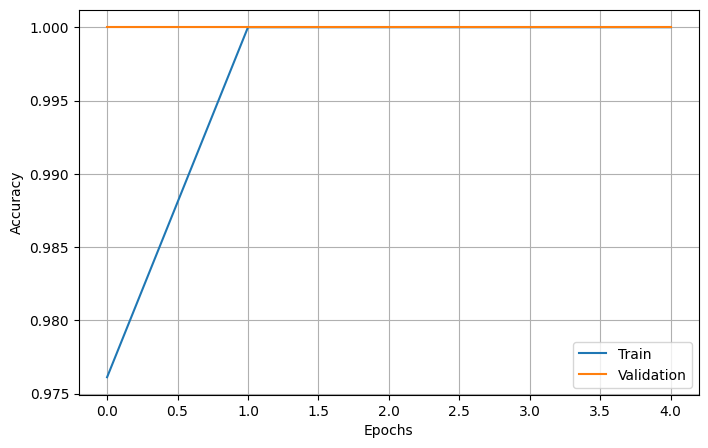

In [ ]:
#Training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

train_resnet18(
    model=rs18model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    # num_epochs=30,
    num_epochs=5,
    scheduler=scheduler
    )

In [ ]:
def get_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            output = model(imgs)
            pred = output.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [ ]:
#unzip the self collected testset
_ = !unzip "/content/small test fruits.zip" -d "/content/small_testset/"
!rm -r /content/small_testset/__MACOSX

In [ ]:
#test loader on self collected testset
from torchvision import datasets, transforms
small_dataset_path = "/content/small_testset/small test fruits"
small_full_ds = datasets.ImageFolder(small_dataset_path, transform=transform)
small_test_loader = DataLoader(small_full_ds, batch_size=len(small_full_ds), shuffle=False, num_workers=2)

The model test accuracy on self collected testset is 0.4666666666666667


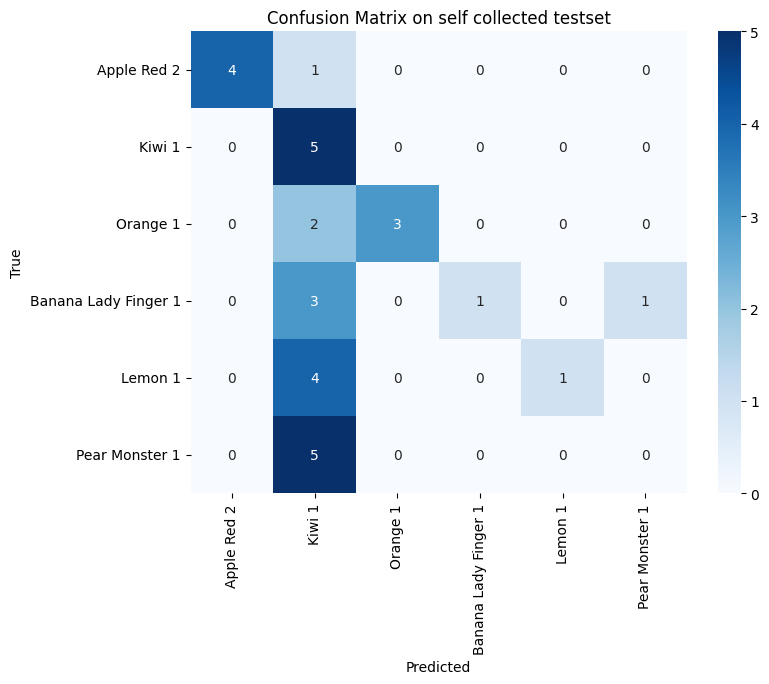

In [ ]:
#test accuracy on the self collected testset
import seaborn as sns
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

small_test_acc = get_accuracy(rs18model, small_test_loader, device)
print(f'The model test accuracy on self collected testset is {small_test_acc}')


def get_prediction(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            output = model(imgs)
            pred = output.argmax(dim=1)
            all_preds.append(pred)
            all_labels.append(labels)
    return torch.cat(all_preds), torch.cat(all_labels)

small_all_preds_tensor, small_all_labels_tensor = get_prediction(rs18model, small_test_loader, device)


cm = confusion_matrix(small_all_labels_tensor.cpu().numpy(), small_all_preds_tensor.cpu().numpy())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Apple Red 2'	,	'Kiwi 1'  , 'Orange 1',
'Banana Lady Finger 1',	'Lemon 1' , 'Pear Monster 1'],
                yticklabels=['Apple Red 2'	,	'Kiwi 1'  , 'Orange 1',
'Banana Lady Finger 1',	'Lemon 1' , 'Pear Monster 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on self collected testset')
plt.show()

The model test accuracy on 6 fruits testset is 1.0


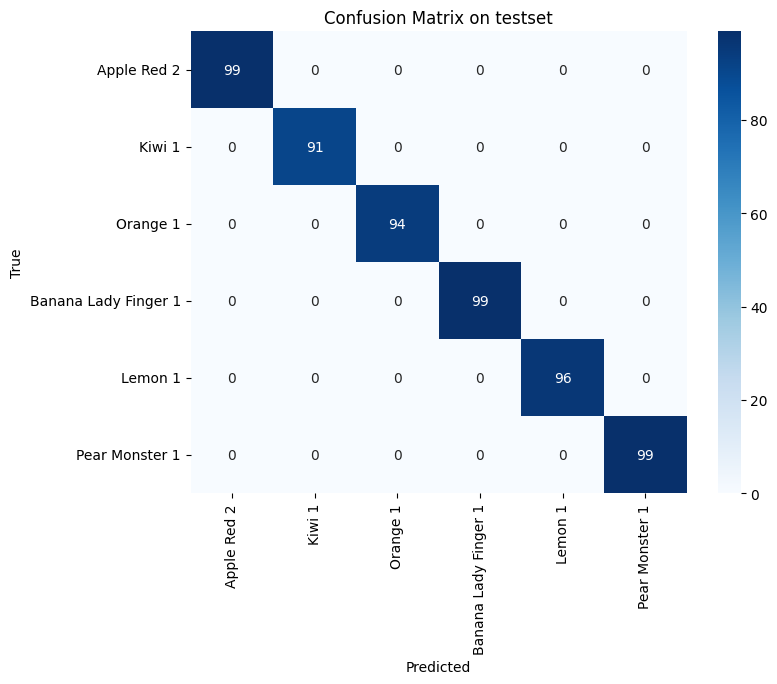

In [ ]:
#test accuracy on the 70/15/15 testset
test_acc = get_accuracy(rs18model, test_loader, device)
print(f'The model test accuracy on 6 fruits testset is {test_acc}')
all_preds_tensor, all_labels_tensor = get_prediction(rs18model, test_loader, device)


cm = confusion_matrix(all_labels_tensor.cpu().numpy(), all_preds_tensor.cpu().numpy())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Apple Red 2'	,	'Kiwi 1'  , 'Orange 1',
'Banana Lady Finger 1',	'Lemon 1' , 'Pear Monster 1'],
                yticklabels=['Apple Red 2'	,	'Kiwi 1'  , 'Orange 1',
'Banana Lady Finger 1',	'Lemon 1' , 'Pear Monster 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on testset')
plt.show()